In [1]:
# install libraries
# !pip install requests pandas nltk textblob vaderSentiment beautifulsoup4 matplotlib seaborn wordcloud plotly

## NEWS API
[News API](https://newsapi.org/register)

Account detail
bala.sbm.kk@gmail.com
Demo@1234

api key
f18eab0734014db589aa291c1f6ee071

In [2]:
# Download NLTK data

# import nltk
# nltk.download('punkt', quiet=True)
# nltk.download('stopwords', quiet=True)
# nltk.download('averaged_perceptron_tagger', quiet=True)
# nltk.download('punkt_tab', quiet=True)
# nltk.download('averaged_perceptron_tagger_eng')

print("✅ All dependencies installed and ready!")

✅ All dependencies installed and ready!


In [3]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime

# ── Data handling ────────────────────────────────────────────────
import pandas as pd

# ── NLP ──────────────────────────────────────────────────────────

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup

# ── Visualization ─────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print('imported successfully...')

imported successfully...


In [4]:
NEWS_API_KEY = "f18eab0734014db589aa291c1f6ee071"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us"
BASE_URL = "https://newsapi.org/v2"

In [5]:
all_articles = []
def fetch_top_headlines(category:str, country:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/top-headlines"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "category": category,
       "country": country,
       "pageSize" : page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles


for cat in CATEGORIES:
   articles = fetch_top_headlines(category=cat, country=COUNTRY)
   for art in articles:
       art["query_category"] = cat
   all_articles.extend(articles)
print(all_articles)


https://newsapi.org/v2/top-headlines
{'apiKey': 'f18eab0734014db589aa291c1f6ee071', 'category': 'technology', 'country': 'us', 'pageSize': 1}
<Response [200]>
[{'source': {'id': 'ars-technica', 'name': 'Ars Technica'}, 'author': 'Andrew Cunningham', 'title': 'Which Macs are suffering from shortages—and where are things getting worse? - Ars Technica', 'description': 'There are a couple signs of strain beyond the MacBook Neo and the desktops.', 'url': 'https://arstechnica.com/gadgets/2026/05/were-tracking-423-mac-configurations-to-see-how-apple-is-handling-shortages/', 'urlToImage': 'https://cdn.arstechnica.net/wp-content/uploads/2026/05/IMG_2326-1152x648.jpeg', 'publishedAt': '2026-05-08T15:00:27Z', 'content': None}]
https://newsapi.org/v2/top-headlines
{'apiKey': 'f18eab0734014db589aa291c1f6ee071', 'category': 'business', 'country': 'us', 'pageSize': 1}
<Response [200]>
[]
[{'source': {'id': 'ars-technica', 'name': 'Ars Technica'}, 'author': 'Andrew Cunningham', 'title': 'Which Macs ar

In [6]:
def fetch_by_keyword(query:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/everything"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "q": query,
       "language": "en",
       "sortBy": "publishedAt",
       "pageSize": page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles


for query in SEARCH_QUERIES:
   articles = fetch_by_keyword(query=query)
   for art in articles:
       art["query_category"] = f"kw:{query}"
   all_articles.extend(articles)


for art in all_articles:
   print(art)

https://newsapi.org/v2/everything
{'apiKey': 'f18eab0734014db589aa291c1f6ee071', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'Mediaite'}, 'author': 'Zachary Leeman', 'title': '‘It’s Insane!’ Californians Fume Over $6 Gas In Scathing MS NOW Segment', 'description': "MS NOW reporter Laura Haefeli presented a segment on the network on Friday that highlighted just how desperate California's gas and oil situation has become.\nThe post ‘It’s Insane!’ Californians Fume Over $6 Gas In Scathing MS NOW Segment first appeared on Me…", 'url': 'https://www.mediaite.com/media/tv/its-insane-californians-fume-over-6-gas-in-scathing-ms-now-segment/', 'urlToImage': 'https://www.mediaite.com/wp-content/uploads/2026/05/ms.jpg', 'publishedAt': '2026-05-08T16:56:14Z', 'content': 'MS NOW reporter Laura Haefeli presented a segment on the network on Friday that highlighted just how desperate California’s gas and oil situation has b

In [7]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
   rows = []
   for art in articles:
       rows.append({
           "title": art.get("title") or "",
           "description" : art.get("description") or "",
           "source" : art.get("source", {}).get("name") or "Unknown",
           "url": art.get("url") or "",
           "published_at" : art.get("publishedAt") or "",
           "category" : art.get("query_category"),
           "full_text" : " ".join(filter(None, [
               art.get("title") or "",
               art.get("description") or "",
               art.get("content") or ""
           ]))
       })
   df = pd.DataFrame(rows)
   return df


df = articles_to_dataframe(all_articles)
df.head()

,title,description,source,url,published_at,category,full_text
0,Which Macs are suffering from shortages—and wh...,There are a couple signs of strain beyond the ...,Ars Technica,https://arstechnica.com/gadgets/2026/05/were-t...,2026-05-08T15:00:27Z,technology,Which Macs are suffering from shortages—and wh...
1,‘It’s Insane!’ Californians Fume Over $6 Gas I...,MS NOW reporter Laura Haefeli presented a segm...,Mediaite,https://www.mediaite.com/media/tv/its-insane-c...,2026-05-08T16:56:14Z,kw:economy,‘It’s Insane!’ Californians Fume Over $6 Gas I...
2,NVIDIA (NVDA) Gains Another Enterprise AI Win ...,"With an upside potential of 35.94%, NVIDIA Cor...",Yahoo Entertainment,https://finance.yahoo.com/sectors/technology/a...,2026-05-08T16:58:50Z,kw:artificial intelligence,NVIDIA (NVDA) Gains Another Enterprise AI Win ...


In [8]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
   "url":         re.compile(r'https?://\S+'),
   #before → "Read more at https://bbc.com/news/article-123 today"
   #after  → "Read more at   today"
   "html_tag":    re.compile(r'<[^>]+>'),
   #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
   #after  → " BREAKING:  Markets  fall  sharply"
   "punctuation": re.compile(r'[^a-zA-Z\s]'),
   #before → "Apple stock up 3.4% — best day since 2021!"
   #after  → "Apple stock up      best day since      "
   "extra_space": re.compile(r'\s+'),
   #before → "Apple   stock    up      best   day"
   #after  → "Apple stock up best day"
   "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
   #input   → "AAPL and TSLA both rose as NASA announced funding"
   #extracts → ["AAPL", "TSLA", "NASA"]
   "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
   #input    → "Elon Musk met Tim Cook in New York yesterday"
   #extracts → ["Elon Musk", "Tim Cook", "New York"]
   "year":        re.compile(r'\b(19|20)\d{2}\b'),
   #input    → "The 2024 budget follows the 2023 deficit report"
   #extracts → ["2024", "2023"]
   "number":      re.compile(r'\b\d+\.?\d*\b'),
   #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
   #extracts → ["4.2", "1"]
   "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
   #before → "The economy shrank [+247 chars]"
   #after  → "The economy shrank  "
}
print(PATTERNS)

{'url': re.compile('https?://\\S+'), 'html_tag': re.compile('<[^>]+>'), 'punctuation': re.compile('[^a-zA-Z\\s]'), 'extra_space': re.compile('\\s+'), 'ticker': re.compile('\\b[A-Z]{2,5}\\b'), 'proper_noun': re.compile('\\b[A-Z][a-z]+(?:\\s[A-Z][a-z]+)+'), 'year': re.compile('\\b(19|20)\\d{2}\\b'), 'number': re.compile('\\b\\d+\\.?\\d*\\b'), 'chars_bracket': re.compile('\\[\\+?\\d+\\s*chars?\\]')}


In [9]:
def clean_text(text: str) -> str:
   """Full regex cleaning pipeline for NLP."""
   text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
   text = PATTERNS["url"].sub(' ', text)             # remove URLs
   text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
   text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
   text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
   return text.strip().lower()

In [10]:
print(clean_text('Stocks fell 4.2 points and GDP grew by 1 percent'))

stocks fell points and gdp grew by percent


In [11]:
def extract_proper_nouns(text: str) -> list:
   """Extract likely named entities using a regex heuristic."""
   return PATTERNS["proper_noun"].findall(text)

print(extract_proper_nouns('Elon Musk met Tim Cook in New York yesterday'))

['Elon Musk', 'Tim Cook', 'New York']


In [12]:
def extract_tickers(text: str) -> list:
   """Extract stock ticker / acronym candidates."""
   return PATTERNS["ticker"].findall(text)

In [13]:
df["clean_text"]    = df["full_text"].apply(clean_text)

In [14]:
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)

In [15]:
df["tickers"]       = df["title"].apply(extract_tickers)

In [16]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)

{'them', 'have', 'out', 'and', 'be', 'whom', 'had', 'its', 'between', 'her', 'o', 'mightn', 'wasn', 'yours', "we'll", 'this', 'with', 'should', 'his', 'just', 'both', "doesn't", 'very', "weren't", 'down', 'those', 'same', "they're", 'ma', 'it', 'or', "haven't", 'of', 'ourselves', 'any', 'your', "aren't", 'mustn', 'once', "we're", 'then', 'an', 'each', 'needn', "mightn't", "couldn't", 'how', 'themselves', 'won', "needn't", 'that', 'herself', "that'll", 'so', 'than', 'their', "isn't", 'above', "they'll", 'about', 'd', 'do', "it'll", 'no', 'she', 'don', "she'd", "they've", 'our', 'were', 'is', 'me', 'during', 'didn', 'further', 'nor', 'some', 'these', 'hers', 'more', 't', "we'd", "you've", "mustn't", "he's", 'himself', "shan't", 'if', 'on', 'y', "you'd", 'where', 's', 'in', "i've", 'only', 'into', 'i', 'does', 'which', "she's", "you'll", "he'd", 'yourselves', "i'll", "don't", "they'd", 'we', 'they', "he'll", 'by', 'through', 'below', 'up', 'll', 'wouldn', 'yourself', 'theirs', 'been', 'bu

In [17]:
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                  'would', 'could', 'may', 'will', 'get', 'got', 'year',
                  'first', 'last', 'week', 'day', 'time', 'report'])

In [18]:
def tokenize_and_filter(text: str) -> list:
   """Tokenize text and remove stopwords & short tokens."""
   tokens = word_tokenize(text)
   print('split into words', tokens)                            # split into words
   tokens = [t for t in tokens if t.isalpha()]    
   print(' keep only alphabetic', tokens)        # keep only alphabetic
   tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
   print('remove stopwords', tokens)
   tokens = [t for t in tokens if len(t) > 2]             # remove very short words
   print('remove very short words', tokens)
   return tokens

In [19]:
print(tokenize_and_filter('The 2024 budget by follows the 2023 deficit report'))

split into words ['The', '2024', 'budget', 'by', 'follows', 'the', '2023', 'deficit', 'report']
 keep only alphabetic ['The', 'budget', 'by', 'follows', 'the', 'deficit', 'report']
remove stopwords ['The', 'budget', 'follows', 'deficit']
remove very short words ['The', 'budget', 'follows', 'deficit']
['The', 'budget', 'follows', 'deficit']


In [20]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers
0,Which Macs are suffering from shortages—and wh...,There are a couple signs of strain beyond the ...,Ars Technica,https://arstechnica.com/gadgets/2026/05/were-t...,2026-05-08T15:00:27Z,technology,Which Macs are suffering from shortages—and wh...,which macs are suffering from shortages and wh...,"[Which Macs, Ars Technica There]",[]
1,‘It’s Insane!’ Californians Fume Over $6 Gas I...,MS NOW reporter Laura Haefeli presented a segm...,Mediaite,https://www.mediaite.com/media/tv/its-insane-c...,2026-05-08T16:56:14Z,kw:economy,‘It’s Insane!’ Californians Fume Over $6 Gas I...,it s insane californians fume over gas in scat...,"[Californians Fume Over, Gas In Scathing, Laur...","[MS, NOW]"
2,NVIDIA (NVDA) Gains Another Enterprise AI Win ...,"With an upside potential of 35.94%, NVIDIA Cor...",Yahoo Entertainment,https://finance.yahoo.com/sectors/technology/a...,2026-05-08T16:58:50Z,kw:artificial intelligence,NVIDIA (NVDA) Gains Another Enterprise AI Win ...,nvidia nvda gains another enterprise ai win as...,"[Gains Another Enterprise, Win As Adoption Con...","[NVDA, AI]"


In [21]:
# Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)

split into words ['which', 'macs', 'are', 'suffering', 'from', 'shortages', 'and', 'where', 'are', 'things', 'getting', 'worse', 'ars', 'technica', 'there', 'are', 'a', 'couple', 'signs', 'of', 'strain', 'beyond', 'the', 'macbook', 'neo', 'and', 'the', 'desktops']
 keep only alphabetic ['which', 'macs', 'are', 'suffering', 'from', 'shortages', 'and', 'where', 'are', 'things', 'getting', 'worse', 'ars', 'technica', 'there', 'are', 'a', 'couple', 'signs', 'of', 'strain', 'beyond', 'the', 'macbook', 'neo', 'and', 'the', 'desktops']
remove stopwords ['macs', 'suffering', 'shortages', 'things', 'getting', 'worse', 'ars', 'technica', 'couple', 'signs', 'strain', 'beyond', 'macbook', 'neo', 'desktops']
remove very short words ['macs', 'suffering', 'shortages', 'things', 'getting', 'worse', 'ars', 'technica', 'couple', 'signs', 'strain', 'beyond', 'macbook', 'neo', 'desktops']
split into words ['it', 's', 'insane', 'californians', 'fume', 'over', 'gas', 'in', 'scathing', 'ms', 'now', 'segment'

In [22]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)

In [23]:
print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
   print(f"  {word:20s} {count:4d}")

Total tokens (after cleaning): 102
Unique tokens: 63

Top 20 most frequent words:
  gas                     4
  segment                 4
  nvidia                  4
  haefeli                 3
  nvda                    3
  insane                  2
  californians            2
  fume                    2
  scathing                2
  reporter                2
  laura                   2
  presented               2
  network                 2
  friday                  2
  highlighted             2
  desperate               2
  california              2
  oil                     2
  situation               2
  become                  2


In [24]:
# ── Visualize: Top 25 words bar chart ───────────────────────────
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)

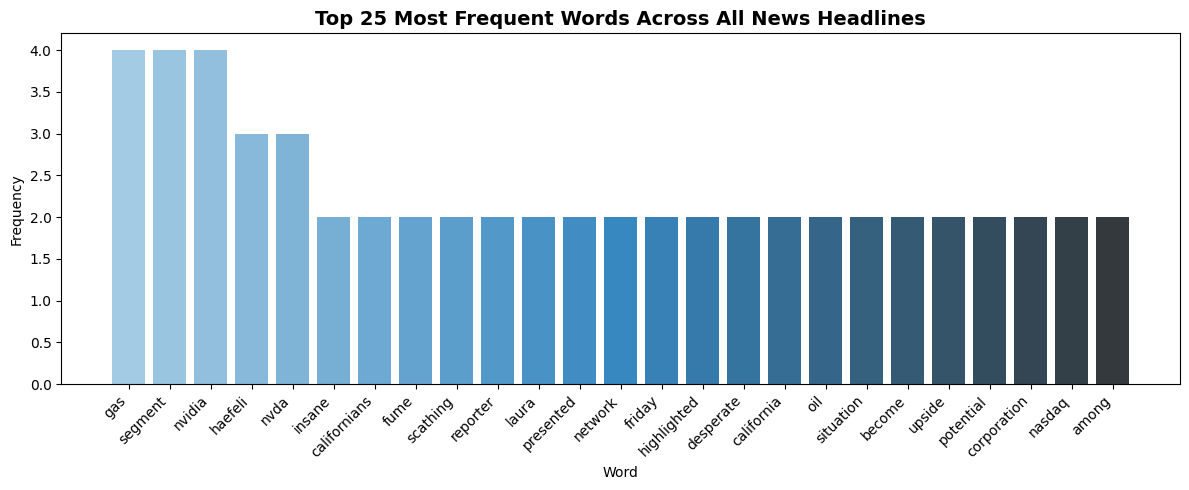

✅ Frequency chart displayed


In [25]:
plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [26]:
print(all_tokens)
text_for_cloud = " ".join(all_tokens)
print(text_for_cloud)

['macs', 'suffering', 'shortages', 'things', 'getting', 'worse', 'ars', 'technica', 'couple', 'signs', 'strain', 'beyond', 'macbook', 'neo', 'desktops', 'insane', 'californians', 'fume', 'gas', 'scathing', 'segment', 'reporter', 'laura', 'haefeli', 'presented', 'segment', 'network', 'friday', 'highlighted', 'desperate', 'california', 'gas', 'oil', 'situation', 'become', 'post', 'insane', 'californians', 'fume', 'gas', 'scathing', 'segment', 'appeared', 'reporter', 'laura', 'haefeli', 'presented', 'segment', 'network', 'friday', 'highlighted', 'desperate', 'california', 'gas', 'oil', 'situation', 'become', 'haefeli', 'joined', 'anchor', 'ana', 'cabrera', 'nvidia', 'nvda', 'gains', 'another', 'enterprise', 'win', 'adoption', 'continues', 'expand', 'upside', 'potential', 'nvidia', 'corporation', 'nasdaq', 'nvda', 'among', 'tech', 'stocks', 'make', 'millionaire', 'april', 'liveramp', 'upside', 'potential', 'nvidia', 'corporation', 'nasdaq', 'nvda', 'among', 'tech', 'stocks', 'make', 'milli

In [27]:
wc = WordCloud(
   width=900, height=400,
   background_color='white',
   colormap='RdYlGn',
   max_words=150,
   collocations=False
).generate(text_for_cloud)

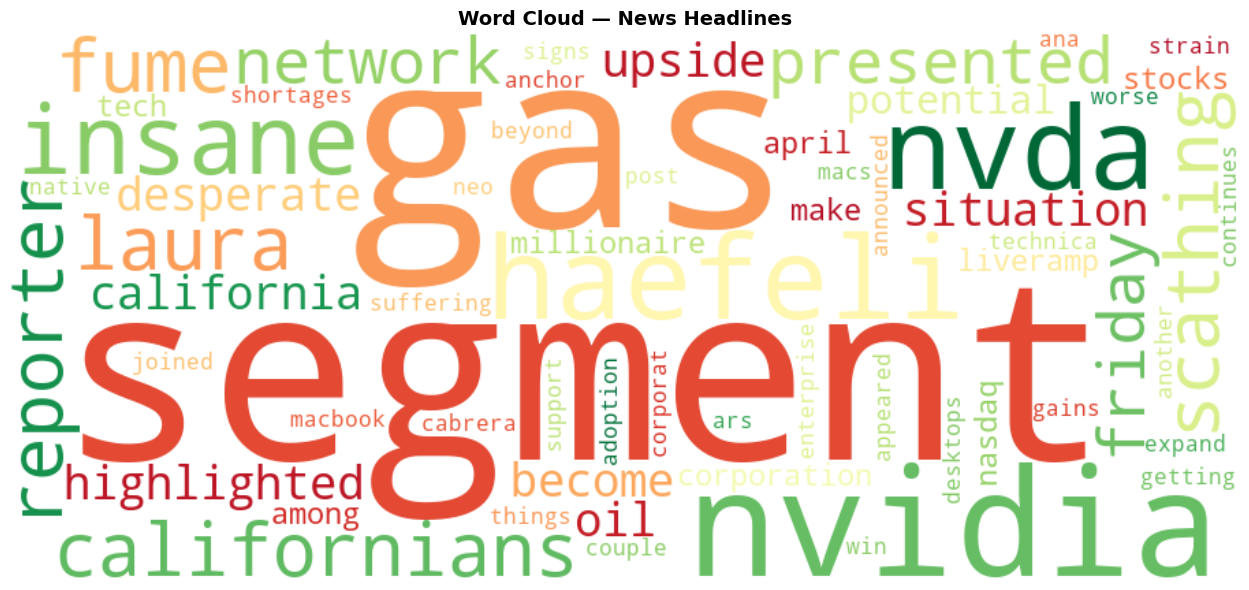

✅ Word cloud displayed


In [28]:
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [29]:
tagged = nltk.pos_tag(df["tokens"][0])
print(tagged)

[('macs', 'NN'), ('suffering', 'VBG'), ('shortages', 'NNS'), ('things', 'NNS'), ('getting', 'VBG'), ('worse', 'JJR'), ('ars', 'NNS'), ('technica', 'JJ'), ('couple', 'NN'), ('signs', 'NNS'), ('strain', 'VBP'), ('beyond', 'IN'), ('macbook', 'NN'), ('neo', 'JJ'), ('desktops', 'NNS')]


In [30]:
# ──Part-of-Speech (POS) tagging  — identify noun-heavy vs action-heavy headlines ──
def pos_tag_summary(tokens: list) -> dict:
   """Return counts of nouns, verbs, adjectives in a token list."""
   tagged = nltk.pos_tag(tokens)
   pos_counts = {"NN": 0, "VB": 0, "JJ": 0}  # nouns, verbs, adjectives
   for _, tag in tagged:
       if tag.startswith("NN"): pos_counts["NN"] += 1
       elif tag.startswith("VB"): pos_counts["VB"] += 1
       elif tag.startswith("JJ"): pos_counts["JJ"] += 1
   return pos_counts

In [31]:
sample_df = df.head(50).copy()

In [32]:
sample_df["pos_tags"] = sample_df["tokens"].apply(pos_tag_summary)
sample_df["noun_count"] = sample_df["pos_tags"].apply(lambda x: x["NN"])
sample_df["verb_count"] = sample_df["pos_tags"].apply(lambda x: x["VB"])
sample_df["adj_count"]  = sample_df["pos_tags"].apply(lambda x: x["JJ"])
sample_df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count,pos_tags,noun_count,verb_count,adj_count
0,Which Macs are suffering from shortages—and wh...,There are a couple signs of strain beyond the ...,Ars Technica,https://arstechnica.com/gadgets/2026/05/were-t...,2026-05-08T15:00:27Z,technology,Which Macs are suffering from shortages—and wh...,which macs are suffering from shortages and wh...,"[Which Macs, Ars Technica There]",[],"[macs, suffering, shortages, things, getting, ...",15,"{'NN': 8, 'VB': 3, 'JJ': 3}",8,3,3
1,‘It’s Insane!’ Californians Fume Over $6 Gas I...,MS NOW reporter Laura Haefeli presented a segm...,Mediaite,https://www.mediaite.com/media/tv/its-insane-c...,2026-05-08T16:56:14Z,kw:economy,‘It’s Insane!’ Californians Fume Over $6 Gas I...,it s insane californians fume over gas in scat...,"[Californians Fume Over, Gas In Scathing, Laur...","[MS, NOW]","[insane, californians, fume, gas, scathing, se...",47,"{'NN': 34, 'VB': 8, 'JJ': 3}",34,8,3
2,NVIDIA (NVDA) Gains Another Enterprise AI Win ...,"With an upside potential of 35.94%, NVIDIA Cor...",Yahoo Entertainment,https://finance.yahoo.com/sectors/technology/a...,2026-05-08T16:58:50Z,kw:artificial intelligence,NVIDIA (NVDA) Gains Another Enterprise AI Win ...,nvidia nvda gains another enterprise ai win as...,"[Gains Another Enterprise, Win As Adoption Con...","[NVDA, AI]","[nvidia, nvda, gains, another, enterprise, win...",40,"{'NN': 19, 'VB': 5, 'JJ': 8}",19,5,8


In [33]:
print("POS distribution (sample of 50 headlines):")
print(f"  Avg nouns per headline:      {sample_df['noun_count'].mean():.1f}")
print(f"  Avg verbs per headline:      {sample_df['verb_count'].mean():.1f}")
print(f"  Avg adjectives per headline: {sample_df['adj_count'].mean():.1f}")

POS distribution (sample of 50 headlines):
  Avg nouns per headline:      20.3
  Avg verbs per headline:      5.3
  Avg adjectives per headline: 4.7


In [34]:
# ── Initialise VADER ─────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()

In [35]:
def vader_sentiment(text: str) -> dict:
   """Run VADER on raw (uncleaned) text — VADER works best on original text."""
   scores = vader.polarity_scores(text)
   compound = scores['compound']
   if compound >= 0.05:
       label = "Positive"
   elif compound <= -0.05:
       label = "Negative"
   else:
       label = "Neutral"
   return {"vader_compound": compound,
           "vader_pos": scores['pos'],
           "vader_neu": scores['neu'],
           "vader_neg": scores['neg'],
           "vader_label": label}

In [36]:
def textblob_sentiment(text: str) -> dict:
   """Run TextBlob on text."""
   blob = TextBlob(text)
   pol  = blob.sentiment.polarity
   subj = blob.sentiment.subjectivity
   if pol > 0.05:     label = "Positive"
   elif pol < -0.05:  label = "Negative"
   else:              label = "Neutral"
   return {"tb_polarity": pol, "tb_subjectivity": subj, "tb_label": label}

In [37]:
# ── Apply to every headline (use title + description for best results) ─
print("Running sentiment analysis...")
vader_results  = df["full_text"].apply(vader_sentiment).apply(pd.Series)
textblob_results = df["full_text"].apply(textblob_sentiment).apply(pd.Series)

Running sentiment analysis...


In [38]:
df = pd.concat([df, vader_results, textblob_results], axis=1)

In [39]:
# Consensus label (agree → use it, disagree → call it Neutral)
def consensus_label(row):
   if row["vader_label"] == row["tb_label"]:
       return row["vader_label"]
   # If one says Neutral and other says Positive/Negative, trust the non-neutral one
   if row["vader_label"] == "Neutral": return row["tb_label"]
   if row["tb_label"]    == "Neutral": return row["vader_label"]
   return "Neutral"  # conflicting non-neutral → call it Neutral

In [40]:
df["consensus_label"] = df.apply(consensus_label, axis=1)

In [41]:
print(f"\n✅ Sentiment analysis complete on {len(df)} articles")
print("\nConsensus label distribution:")
print(df["consensus_label"].value_counts())


✅ Sentiment analysis complete on 3 articles

Consensus label distribution:
consensus_label
Negative    2
Positive    1
Name: count, dtype: int64


In [42]:
print(df[["title", "vader_label", "tb_label", "consensus_label"]].head(10))

                                               title vader_label  tb_label  \
0  Which Macs are suffering from shortages—and wh...    Negative  Negative   
1  ‘It’s Insane!’ Californians Fume Over $6 Gas I...    Negative  Negative   
2  NVIDIA (NVDA) Gains Another Enterprise AI Win ...    Positive  Positive   

  consensus_label  
0        Negative  
1        Negative  
2        Positive  


In [43]:
# ── Show example headlines with their sentiment scores ───────────
cols = ["title", "category", "vader_compound", "tb_polarity", "tb_subjectivity", "consensus_label"]
display_df = df[cols].sort_values("vader_compound", ascending=False)

In [44]:
print("🟢 Top 5 Most POSITIVE headlines:")
for _, row in display_df.head(5).iterrows():
   print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

🟢 Top 5 Most POSITIVE headlines:
  [Positive | score: +0.88] NVIDIA (NVDA) Gains Another Enterprise AI Win As Adoption Continues To Expand
  [Negative | score: -0.75] Which Macs are suffering from shortages—and where are things getting worse? - Ar
  [Negative | score: -0.82] ‘It’s Insane!’ Californians Fume Over $6 Gas In Scathing MS NOW Segment


In [45]:
# ── Visualize 1: Sentiment distribution by category ──────────────
COLOR_MAP = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

In [46]:
cat_sentiment = df.groupby(["category", "consensus_label"]).size().unstack(fill_value=0)
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

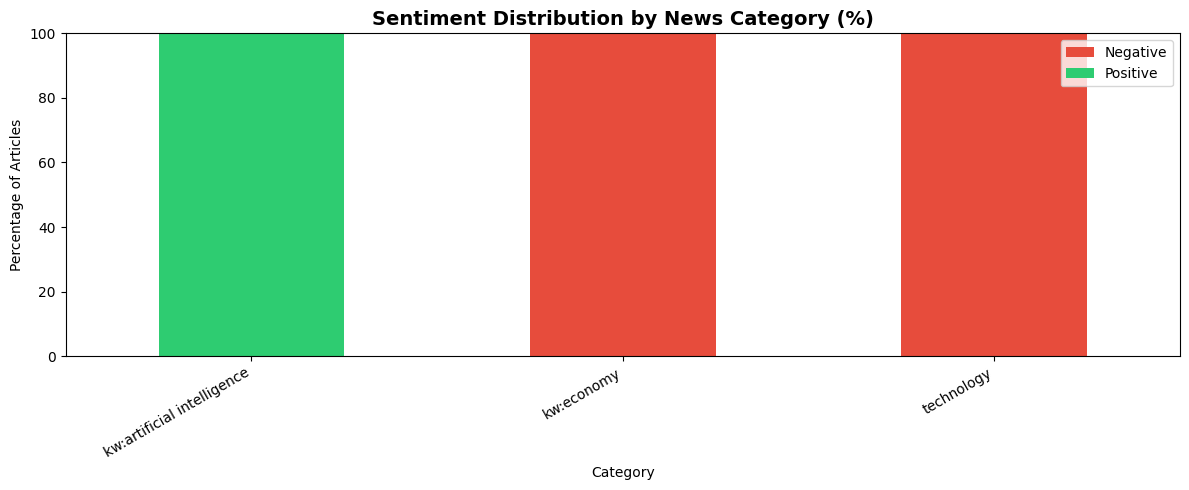

✅ Stacked bar chart displayed


In [47]:
ax = cat_sentiment_pct.plot(
   kind='bar', stacked=True, figsize=(12, 5),
   color=[COLOR_MAP.get(c, '#cccccc') for c in cat_sentiment_pct.columns]
)
plt.title("Sentiment Distribution by News Category (%)", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Percentage of Articles")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Stacked bar chart displayed")

In [48]:
HEADERS = {
   "User-Agent": (
       "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
       "AppleWebKit/537.36 (KHTML, like Gecko) "
       "Chrome/120.0.0.0 Safari/537.36"
   )
}

In [49]:
def scrape_article_text(url: str, timeout: int = 8) -> str:
   """
   Scrape full article text from a given URL.
   Returns cleaned paragraph text or empty string on failure.
   """
   try:
       response = requests.get(url, headers=HEADERS, timeout=timeout)
       response.raise_for_status()                        # raise on 4xx/5xx
       soup = BeautifulSoup(response.text, 'html.parser')
       # ── Strategy 1: look for <article> tag (modern sites) ────
       article_tag = soup.find('article')
       if article_tag:
           paragraphs = article_tag.find_all('p')
       else:
           # ── Strategy 2: fall back to all <p> tags ────────────
           paragraphs = soup.find_all('p')
       # Extract and join non-empty paragraph text
       text = ' '.join(
           p.get_text(strip=True)
           for p in paragraphs
           if len(p.get_text(strip=True)) > 40   # skip tiny/nav paragraphs
       )
       return text[:3000]   # cap at 3000 chars to keep things fast
   except Exception as e:
       return ""   # silently skip failed URLs

In [50]:
# ── Scrape a small sample (5 articles) to demonstrate ────────────
# (Scraping all 100+ would be slow — use a subset for the lab)
SCRAPE_SAMPLE = 5
scrape_sample = df[df["url"].str.startswith("http")].head(SCRAPE_SAMPLE).copy()
print(f"Scraping {SCRAPE_SAMPLE} full articles...")
scraped_texts = []
for i, (idx, row) in enumerate(scrape_sample.iterrows()):
   text = scrape_article_text(row["url"])
   word_count = len(text.split()) if text else 0
   scraped_texts.append(text)
   status = "✅" if text else "⚠️ "
   print(f"  {status} [{i+1}/{SCRAPE_SAMPLE}] {row['source']:20s} → {word_count:4d} words")
   time.sleep(1)   # be polite — 1 second between requests
scrape_sample["scraped_text"] = scraped_texts
print("\nDone!")

Scraping 5 full articles...
  ✅ [1/5] Ars Technica         →  525 words
  ✅ [2/5] Mediaite             →  506 words
  ✅ [3/5] Yahoo Entertainment  →  355 words

Done!


In [51]:
# ── Inspect what was scraped ─────────────────────────────────────
for _, row in scrape_sample.iterrows():
   if row["scraped_text"]:
       print(f"\n{'='*60}")
       print(f"SOURCE  : {row['source']}")
       print(f"HEADLINE: {row['title'][:80]}")
       print(f"SCRAPED TEXT PREVIEW (first 300 chars):")
       print(f"  {row['scraped_text'][:300]}...")
       break   # show just one example
# ── Analyse scraped text with BeautifulSoup metadata extraction ──
def extract_page_metadata(url: str) -> dict:
   """
   Extract metadata (og:title, og:description, keywords) from a page.
   Demonstrates BeautifulSoup meta tag parsing.
   """
   try:
       response = requests.get(url, headers=HEADERS, timeout=8)
       soup = BeautifulSoup(response.text, 'html.parser')
       def get_meta(prop):
           tag = soup.find('meta', property=prop) or soup.find('meta', attrs={'name': prop})
           return tag['content'] if tag and tag.get('content') else None
       return {
           "og_title":       get_meta('og:title'),
           "og_description": get_meta('og:description'),
           "meta_keywords":  get_meta('keywords'),
           "h1_tags":        [h.get_text(strip=True) for h in soup.find_all('h1')][:3]
       }
   except Exception:
       return {}


SOURCE  : Ars Technica
HEADLINE: Which Macs are suffering from shortages—and where are things getting worse? - Ar
SCRAPED TEXT PREVIEW (first 300 chars):
  There are a couple signs of strain beyond the MacBook Neo and the desktops. The Apple Macintosh is more than 40 years old, but it’s still going strong, and its recent success was significant enough that Apple CEO Tim Cook called it out duringthe company’s earnings call last week. In particular, Cook...


In [52]:
# Demo on first article
sample_url = df[df["url"].str.startswith("http")]["url"].iloc[0]
meta = extract_page_metadata(sample_url)
print("Page metadata extracted via BeautifulSoup:")
for key, val in meta.items():
   print(f"  {key:20s}: {str(val)[:80]}")

Page metadata extracted via BeautifulSoup:
  og_title            : Which Macs are suffering from shortages—and where are things getting worse?
  og_description      : There are a couple signs of strain beyond the MacBook Neo and the desktops.
  meta_keywords       : None
  h1_tags             : ['Which Macs are suffering from shortages—and where are things getting worse?']


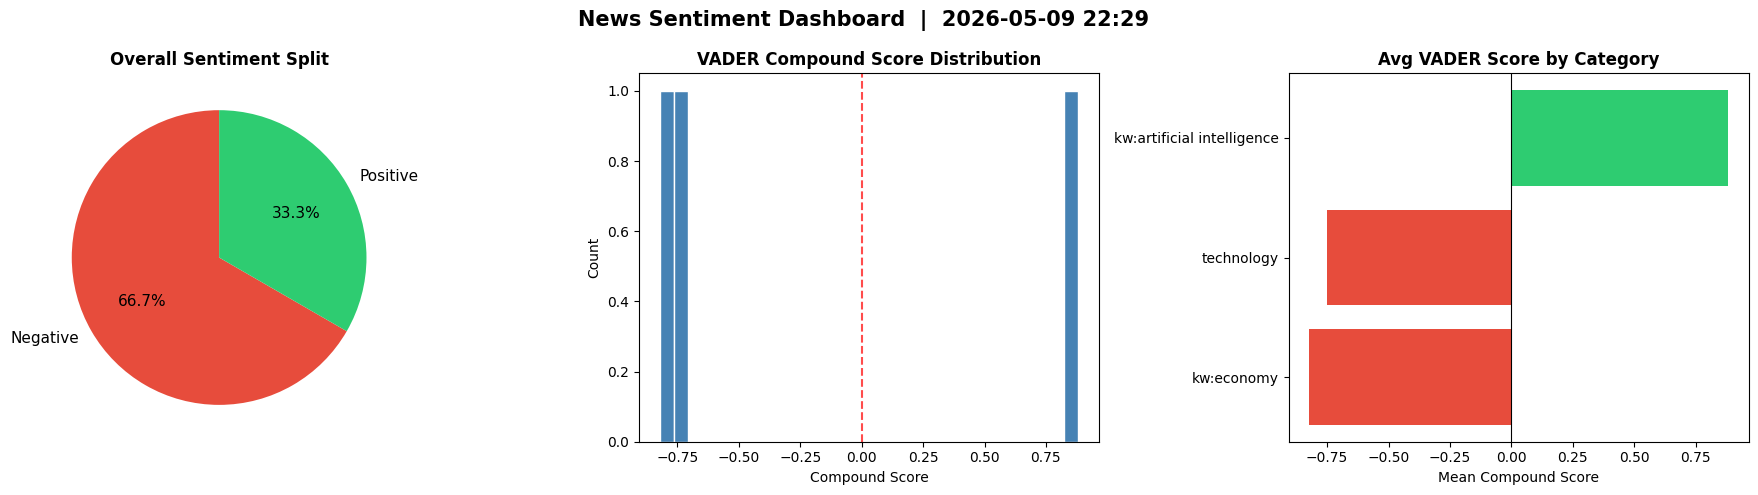

✅ Dashboard Panel 1 displayed


In [53]:
# ── Dashboard Panel 1: Sentiment Overview Pie ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
            fontsize=15, fontweight='bold')
# Panel 1 — Overall pie
counts = df["consensus_label"].value_counts()
axes[0].pie(
   counts.values,
   labels=counts.index,
   colors=[COLOR_MAP[l] for l in counts.index],
   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[0].set_title("Overall Sentiment Split", fontweight='bold')
# Panel 2 — VADER compound distribution histogram
axes[1].hist(df["vader_compound"], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title("VADER Compound Score Distribution", fontweight='bold')
axes[1].set_xlabel("Compound Score")
axes[1].set_ylabel("Count")
# Panel 3 — Average sentiment per category
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes[2].barh(cat_avg.index, cat_avg.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg VADER Score by Category", fontweight='bold')
axes[2].set_xlabel("Mean Compound Score")
plt.tight_layout()
plt.show()
print("✅ Dashboard Panel 1 displayed")

In [54]:
# ── Print final summary ──────────────────────────────────────────
print("="*60)
print(" NEWS SENTIMENT DASHBOARD — SUMMARY REPORT")
print(f" Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)
print(f" Total articles analysed : {len(df)}")
print(f" Categories covered      : {', '.join(df['category'].unique())}")
print(f" Unique sources          : {df['source'].nunique()}")
print()
print(" SENTIMENT BREAKDOWN:")
for label, count in df['consensus_label'].value_counts().items():
   pct = count / len(df) * 100
   bar = '█' * int(pct / 3)
   print(f"   {label:10s} {bar:30s} {count:4d} ({pct:.1f}%)")
print()
print(" MOST POSITIVE CATEGORIES:")
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values(ascending=False)
for cat, score in cat_avg.items():
   emoji = '🟢' if score > 0.05 else ('🔴' if score < -0.05 else '⚪')
   print(f"   {emoji} {cat:20s} score: {score:+.3f}")
print()
print(" TOP KEYWORDS IN HEADLINES:")
for word, count in freq_dist.most_common(10):
   print(f"   {word:20s} {count} mentions")
print("="*60)

 NEWS SENTIMENT DASHBOARD — SUMMARY REPORT
 Generated: 2026-05-09 22:29:46
 Total articles analysed : 3
 Categories covered      : technology, kw:economy, kw:artificial intelligence
 Unique sources          : 3

 SENTIMENT BREAKDOWN:
   Negative   ██████████████████████            2 (66.7%)
   Positive   ███████████                       1 (33.3%)

 MOST POSITIVE CATEGORIES:
   🟢 kw:artificial intelligence score: +0.881
   🔴 technology           score: -0.751
   🔴 kw:economy           score: -0.822

 TOP KEYWORDS IN HEADLINES:
   gas                  4 mentions
   segment              4 mentions
   nvidia               4 mentions
   haefeli              3 mentions
   nvda                 3 mentions
   insane               2 mentions
   californians         2 mentions
   fume                 2 mentions
   scathing             2 mentions
   reporter             2 mentions


In [55]:
# ── Export final DataFrame to CSV ────────────────────────────────
output_cols = [
   'title', 'source', 'category', 'published_at',
   'vader_compound', 'vader_label',
   'tb_polarity', 'tb_subjectivity', 'tb_label',
   'consensus_label', 'token_count', 'url'
]
df[output_cols].to_csv('news_sentiment_results.csv', index=False)
print("✅ Results saved to news_sentiment_results.csv")
print(f"   Shape: {df[output_cols].shape}")
df[output_cols].head()

✅ Results saved to news_sentiment_results.csv
   Shape: (3, 12)


,title,source,category,published_at,vader_compound,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label,token_count,url
0,Which Macs are suffering from shortages—and wh...,Ars Technica,technology,2026-05-08T15:00:27Z,-0.7506,Negative,-0.400000,0.600000,Negative,Negative,15,https://arstechnica.com/gadgets/2026/05/were-t...
1,‘It’s Insane!’ Californians Fume Over $6 Gas I...,Mediaite,kw:economy,2026-05-08T16:56:14Z,-0.8217,Negative,-0.592857,0.904762,Negative,Negative,47,https://www.mediaite.com/media/tv/its-insane-c...
2,NVIDIA (NVDA) Gains Another Enterprise AI Win ...,Yahoo Entertainment,kw:artificial intelligence,2026-05-08T16:58:50Z,0.8807,Positive,0.266667,0.800000,Positive,Positive,40,https://finance.yahoo.com/sectors/technology/a...
